<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 0.9802 acc 0.595 | val loss 0.6939 acc 0.713 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.7649 acc 0.668 | val loss 0.7078 acc 0.760


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch  24/100 | LR: 1.38e-04 | train loss 0.0563 acc 0.988 | val loss 0.5909 acc 0.801


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch  25/100 | LR: 1.38e-04 | train loss 0.0364 acc 0.991 | val loss 0.5614 acc 0.824


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch  26/100 | LR: 1.38e-04 | train loss 0.0330 acc 0.992 | val loss 0.5888 acc 0.824

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 26.

[Effici

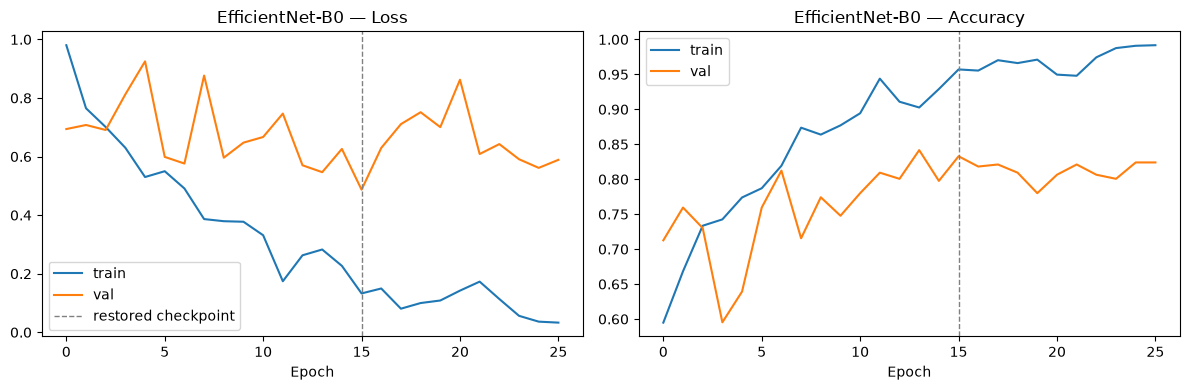

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: off
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Test accuracy: 0.811


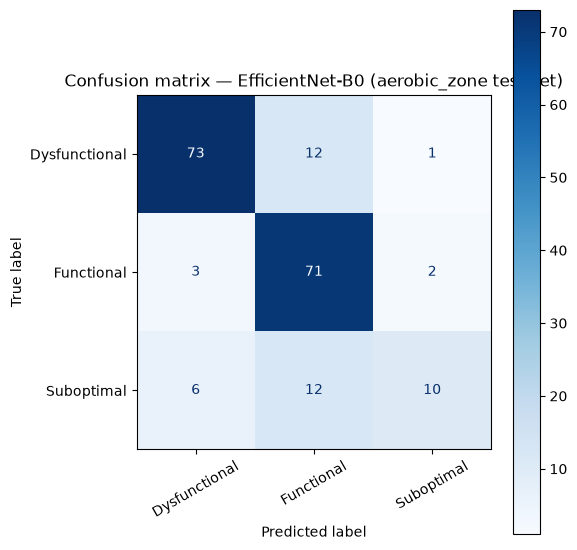

               precision    recall  f1-score   support

Dysfunctional      0.890     0.849     0.869        86
   Functional      0.747     0.934     0.830        76
   Suboptimal      0.769     0.357     0.488        28

     accuracy                          0.811       190
    macro avg      0.802     0.713     0.729       190
 weighted avg      0.815     0.811     0.797       190



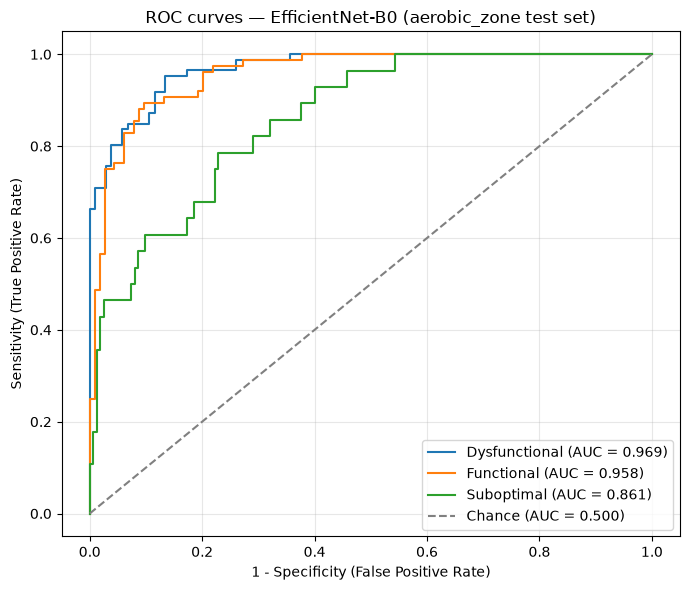

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.969
  Functional     : 0.958
  Suboptimal     : 0.861

Mean AUC (over 3/3 classes with test examples): 0.929


(np.float64(0.8105263157894737),
 {'Dysfunctional': 0.9689177101967799,
  'Functional': 0.9577562326869806,
  'Suboptimal': 0.8608906525573192})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_pad_noaug/results_aerobic_zone_efficientnet_b0_stratified.pkl


Saved model weights to ../models/pad/aerobic_zone_efficientnet_b0_cnn.pt
